In [59]:
import pandas as pd

import sys
sys.path.append("../../utils")
import analysis_untilities as utils

import importlib
importlib.reload(utils)

<module 'analysis_untilities' from '/home/fatduck/git/kaggle/competitions/titanic/../../utils/analysis_untilities.py'>

In [60]:
train_data = pd.read_csv("data/train.csv")
test_data = pd.read_csv("data/test.csv")

In [61]:
utils.overview(train_data)
# utils.overview(test_data)

No.Rows: 891
No.Columns: 12
Columns: 
  - PassengerId    (891 Uniques) (0 Nulls)   int64     
  - Survived       (2 Uniques)   (0 Nulls)   int64     
  - Pclass         (3 Uniques)   (0 Nulls)   int64     
  - Name           (891 Uniques) (0 Nulls)   object    
  - Sex            (2 Uniques)   (0 Nulls)   object    
  - Age            (88 Uniques)  (177 Nulls) float64   
  - SibSp          (7 Uniques)   (0 Nulls)   int64     
  - Parch          (7 Uniques)   (0 Nulls)   int64     
  - Ticket         (681 Uniques) (0 Nulls)   object    
  - Fare           (248 Uniques) (0 Nulls)   float64   
  - Cabin          (147 Uniques) (687 Nulls) object    
  - Embarked       (3 Uniques)   (2 Nulls)   object    


Data Dictionary
Variable	Definition	Key
survival	Survival	0 = No, 1 = Yes
pclass	Ticket class	1 = 1st, 2 = 2nd, 3 = 3rd
sex	Sex	
Age	Age in years	
sibsp	# of siblings / spouses aboard the Titanic	
parch	# of parents / children aboard the Titanic	
ticket	Ticket number	
fare	Passenger fare	
cabin	Cabin number	
embarked	Port of Embarkation	C = Cherbourg, Q = Queenstown, S = Southampton

In [62]:
def testing(data):
    print(data.columns)
    for col in data.columns:
        print(data[col].dtypes, col)

testing(train_data)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')
int64 PassengerId
int64 Survived
int64 Pclass
object Name
object Sex
float64 Age
int64 SibSp
int64 Parch
object Ticket
float64 Fare
object Cabin
object Embarked


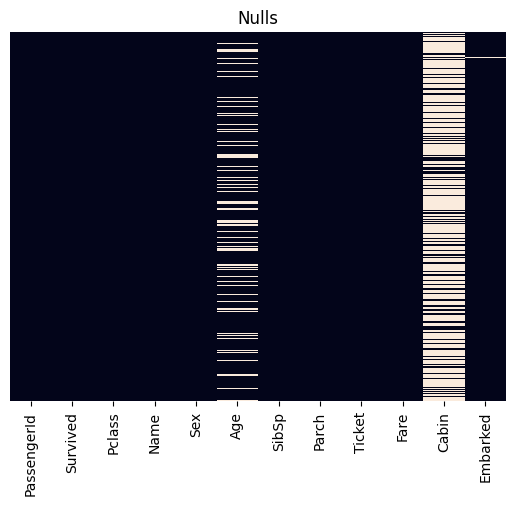

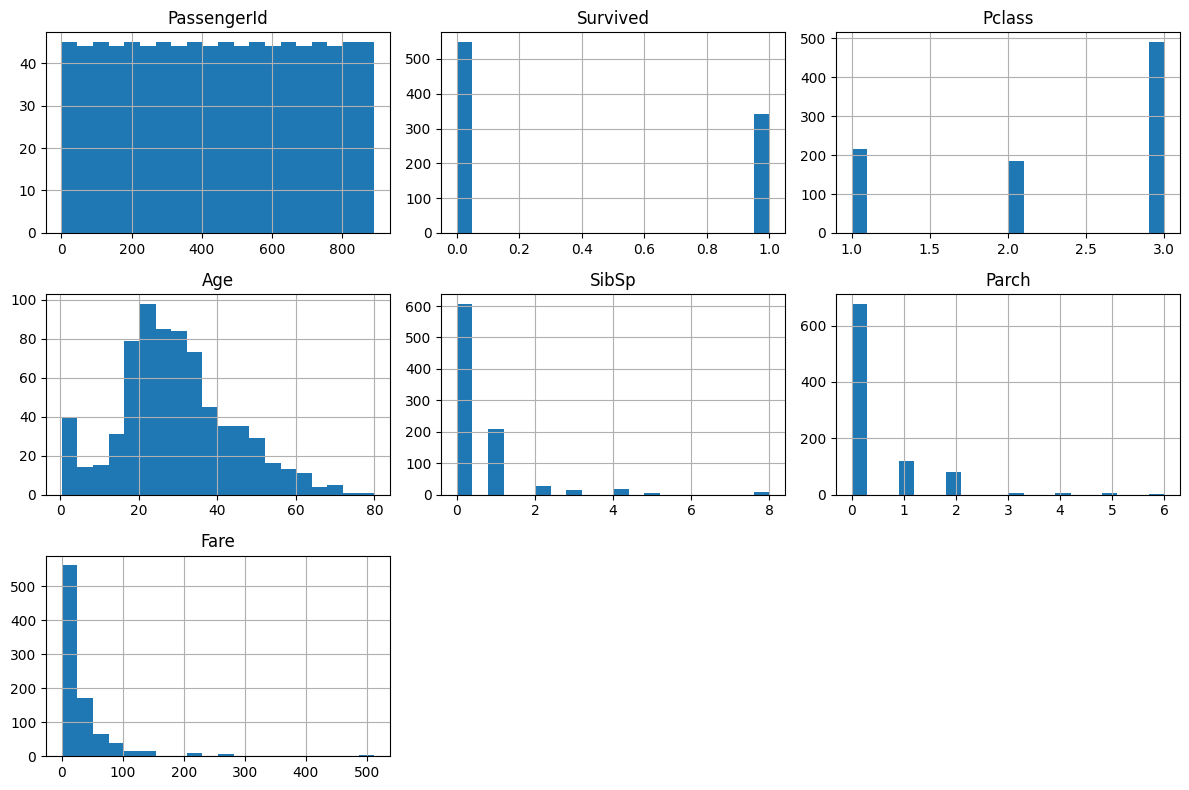

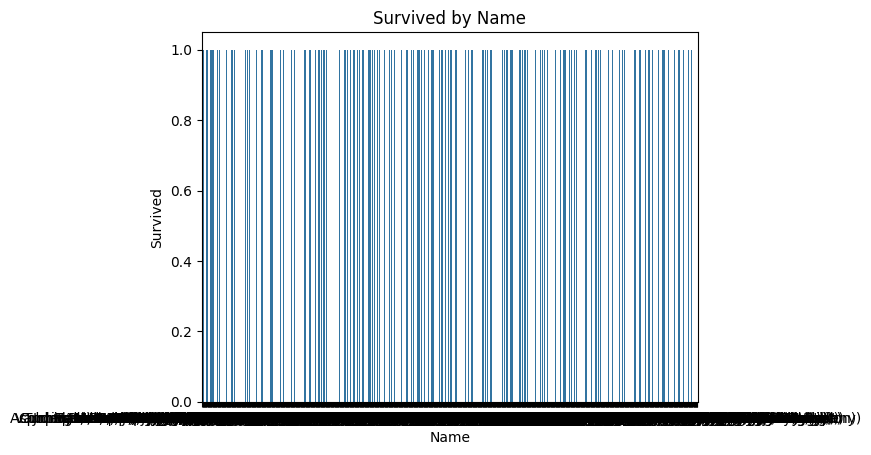

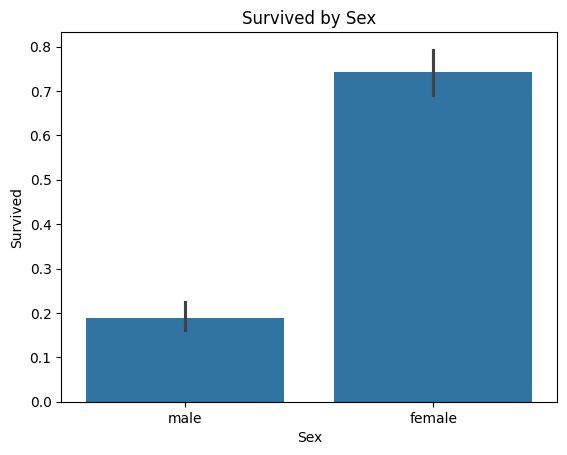

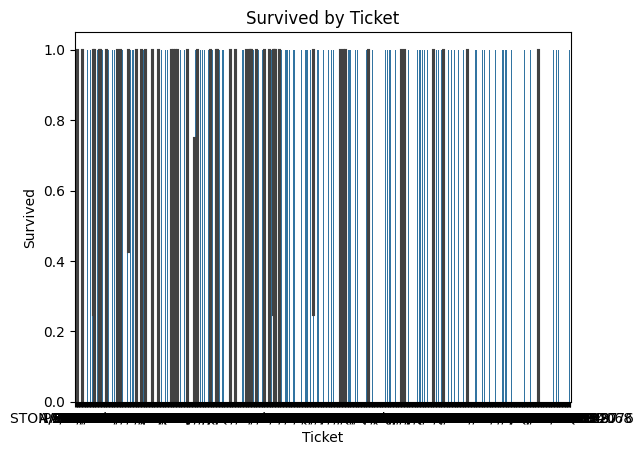

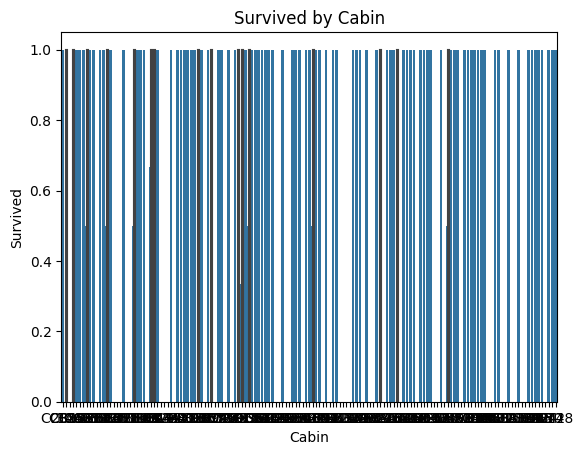

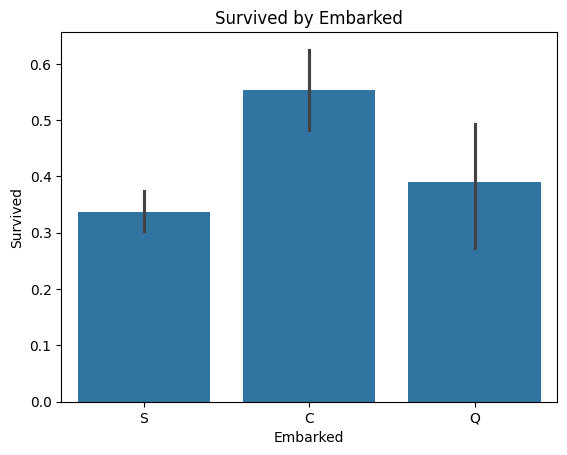

In [63]:
utils.quick_eda(train_data, target="Survived")

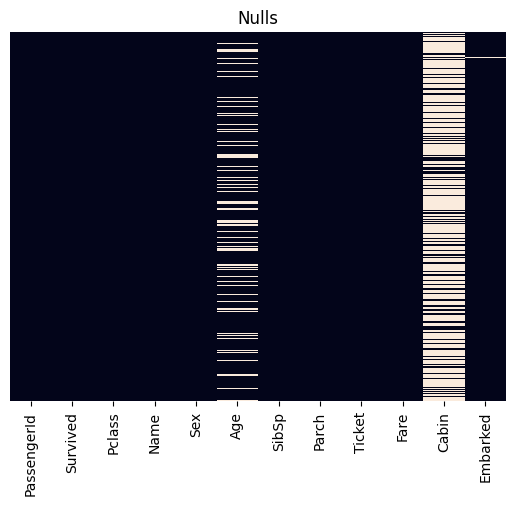

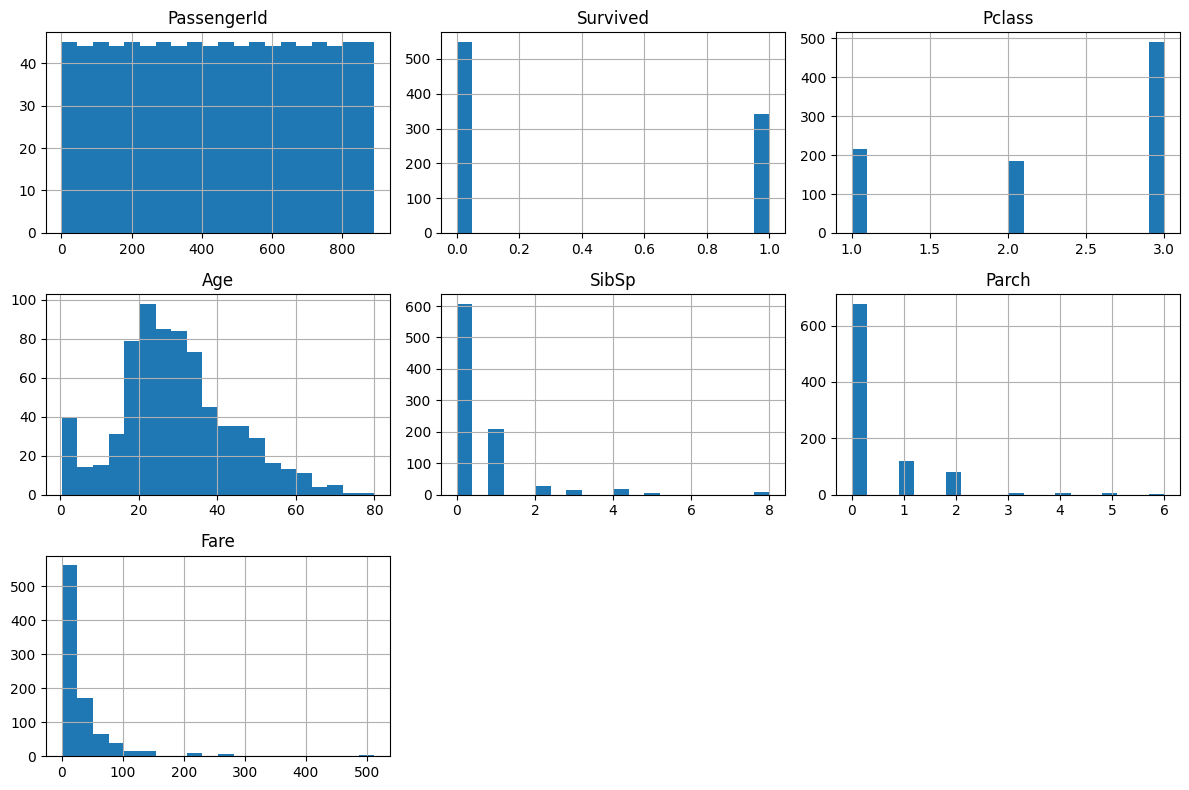

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns
def quick_eda(df, target=None):
    # Null heatmap
    sns.heatmap(df.isnull(), cbar=False, yticklabels=False)
    plt.title("Nulls")
    plt.show()

    # Distributions for numeric cols
    df.hist(figsize=(12, 8), bins=20)
    plt.tight_layout()
    plt.show()

quick_eda(train_data)

In [65]:
test_data.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [66]:
train_data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [67]:
filtering = ["Survived", "Pclass", "Sex", "Age"]
filtered_data = train_data[filtering]

In [68]:
train_data[["Pclass", "Survived"]].groupby(["Pclass"]).mean()

,Survived
Pclass,
1,0.629630
2,0.472826
3,0.242363


In [69]:
train_data[["Sex", "Survived"]].groupby(["Sex"]).mean()

,Survived
Sex,
female,0.742038
male,0.188908


In [70]:
train_data[["Age", "Survived"]].groupby(["Age"]).mean().sort_values(by="Survived", ascending=False)

,Survived
Age,
0.42,1.0
0.67,1.0
0.75,1.0
0.83,1.0
0.92,1.0
...,...
65.00,0.0
70.00,0.0
70.50,0.0


In [71]:
train_data[["SibSp", "Survived"]].groupby(["SibSp"]).mean().sort_values(by="Survived", ascending=False)

,Survived
SibSp,
1,0.535885
2,0.464286
0,0.345395
3,0.250000
4,0.166667
5,0.000000
8,0.000000


In [72]:
train_data[["Embarked", "Survived"]].groupby(["Embarked"]).mean().sort_values(by="Survived", ascending=False)

,Survived
Embarked,
C,0.553571
Q,0.389610
S,0.336957


In [73]:
train_data[["Cabin", "Survived"]].groupby(["Cabin"]).mean().sort_values(by="Survived", ascending=False)

,Survived
Cabin,
A16,1.0
A23,1.0
A20,1.0
A34,1.0
B18,1.0
...,...
E63,0.0
F G63,0.0
F G73,0.0
